        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
import tensorflow as tf

2025-07-03 00:41:03.509154: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751483463.530551  267421 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751483463.536856  267421 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 00:41:03.558452: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


        Select a GPU with a memory limit

In [ ]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin',
    # '/data1/kishoretarafdar/src2D/GIIR/mra'
    # '/data1/kishoretarafdar/src.port/Volterra.mra.live/mra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu




2025-06-21 07:58:09.128267: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750472889.149571 1311506 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750472889.156144 1311506 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-21 07:58:09.178633: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3
3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


I0000 00:00:1750472891.351955 1311506 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


In [2]:
import matplotlib.pyplot as plt

#  MIMO batch 

        export to py file

2025-07-03 00:41:10.529517: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-07-03 00:41:10.529557: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: meherangarh
2025-07-03 00:41:10.529564: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: meherangarh
2025-07-03 00:41:10.529663: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 570.148.8
2025-07-03 00:41:10.529688: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 570.148.8
2025-07-03 00:41:10.529693: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:259] kernel version seems to match DSO: 570.148.8


TensorShape([2, 8, 8, 1])

In [ ]:
import tensorflow as tf
import keras
from TFDWT.DWT2DFB import DWT2D, IDWT2D

@tf.keras.utils.register_keras_serializable()
class LSIVolterraMRAKernel2D(tf.keras.layers.Layer):
    """ VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>. 
        
    
    Shift invariant Linear (m=1) Multiresolution Volterra Kernel
       Input: image x[n1,n2]
       Output: Shift invariant linear monomial y1, i.e., m=1

    --@KKT@03Jul2025"""
    
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(**kwargs)
        self.L = kernel_size
        self.wave = wave
        self.filters = filters
    
    def build(self, input_shape):
        # input_shape: (batch_size, N, N, channels)
        self.N = input_shape[1]
        self.channels = input_shape[-1]

        kernel_shape = (self.L, self.L, input_shape[-1], self.filters)
        # kernel_shape = (self.L, self.L, input_shape[-1])
        self.h1 = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            # regularizer=self.kernel_regularizer,
            name='kernel')
        super().build(input_shape)

    def __makeH(self):
        # Npoint = self.N
        paddings = [
        [0, self.N - self.L],  # height dimension
        [0, self.N - self.L],  # width dimension
        [0,0],
        [0,0] 
        ]
        h1 = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)

        # Create a meshgrid for n1, n2, k1, k2
        n1 = tf.range(self.N)  # [0, 1, ..., N-1]
        n2 = tf.range(self.N)  # [0, 1, ..., N-1]
        k1 = tf.range(self.N)  # [0, 1, ..., N-1]
        k2 = tf.range(self.N)  # [0, 1, ..., N-1]

        # Create a grid of indices for n1, n2, k1, k2
        n1, n2, k1, k2 = tf.meshgrid(n1, n2, k1, k2, indexing='ij')  # Shape (N, N, N, N)

        # Compute circularly shifted indices
        shifted_n1 = tf.math.mod(n1 - k1, self.N)  # Circular shift for n1
        shifted_n2 = tf.math.mod(n2 - k2, self.N)  # Circular shift for n2

        # Gather the values from h using the shifted indices
        h1_shifted = tf.gather_nd(h1, tf.stack([shifted_n1, shifted_n2], axis=-1))
        # h1_shifted = tf.transpose(h1_shifted,perm=[0,2,3,1,4,5])  # n1,:,:,n2 01234 ## very important line!!
        print('++', h1_shifted.shape)
       
        # ### second vectorized upgrade
        def dwtmra(h1_shited):
            # # h1_shifted: (N, N, N, N, in_channels, out_channels)
            N, in_channels, out_channels = self.N, self.channels, self.filters
            num_io = in_channels * out_channels

            # Flatten (in, out) for DWT2D
            hflat = tf.reshape(h1_shifted, (N, N, N, N, num_io))
            hflat_reshape = tf.reshape(hflat, (N*N, N, N, num_io))

            dwt2d = DWT2D(self.wave, clean=False)
            x1 = dwt2d(tf.cast(hflat_reshape, tf.float32))
            x1r = tf.reshape(x1, (N, N, N, N, num_io))

            # Transpose for columnplanewise DWT2D
            x1T = tf.transpose(x1r, [2, 3, 0, 1, 4])
            x1T_reshape = tf.reshape(x1T, (N*N, N, N, num_io))
            x2 = dwt2d(x1T_reshape)
            x2r = tf.reshape(x2, (N, N, N, N, num_io))

            # Transpose back
            HT = tf.transpose(x2r, [2, 3, 0, 1, 4])
            HT = tf.reshape(HT, (N, N, N, N, in_channels, out_channels))
            return HT
        return dwtmra(h1_shifted)     
                    
            # PERFECT but slow    
            # # for in channels
            # h1_n_l = tf.stack([
            #     tf.stack([
            #         tf.transpose(
            #             DWT2D(self.wave, clean=False)(
            #                 tf.transpose(
            #                     DWT2D(self.wave, clean=False)(tf.cast(h1_shifted[...,i,j], dtype=tf.float32)), 
            #                         perm=[1,0,3,2])
            #                         ),
            #                         perm=[1,0,3,2]) for i in range(self.channels)
            #         ],axis=-1) for j in range(self.filters)
            #         ],axis=-1)
            
            # ## vectorized upgrade (perfect and fast)
            # def foo(h1_shifted):
            #     # Example placeholder tensor
            #     # h1_shifted shape: (N, N, N, N, in_channels, out_channels)
            #     # You can replace these with actual values
            #     N = self.N
            #     in_channels = self.channels
            #     out_channels = self.filters
            #     # h1_shifted = tf.random.normal((N, N, N, N, in_channels, out_channels))


            #     def reshape1(h1_shifted):
            #         ##### Step 1: Transpose to bring in_channels and out_channels to the front
            #         # New shape: (in_channels, out_channels, N, N, N, N)
            #         h1_transposed = tf.transpose(h1_shifted, perm=[4, 5, 0, 1, 2, 3])

            #         # Step 2: Reshape to (out_channels * in_channels * N, N, N, N)
            #         new_shape = (out_channels * in_channels * N, N, N, N)
            #         h1_reshaped = tf.reshape(h1_transposed, new_shape)
            #         print(h1_reshaped.shape)
            #         return h1_reshaped
        
            #     h1_reshaped = reshape1(h1_shifted)
            #     transform1 = DWT2D(self.wave, clean=False)(tf.cast(h1_reshaped, dtype=tf.float32))

            #     def reshape1back(transform1):
            #         #####get back to original shape
            #         # Step 1: Reshape back to (in_channels, out_channels, N, N, N, N)
            #         transform1_back = tf.reshape(transform1, (in_channels, out_channels, N, N, N, N))

            #         # Step 2: Transpose back to original shape: (N, N, N, N, in_channels, out_channels)
            #         transform1_back = tf.transpose(transform1_back, perm=[2, 3, 4, 5, 0, 1])
            #         print(transform1_back.shape)
            #         return transform1_back

            #     transform1_back = reshape1back(transform1)
            #     transform1_back = tf.transpose(transform1_back, perm=[1,0,3,2,4,5])

            #     transform1_back_reshaped = reshape1(transform1_back)
            #     transform2 = DWT2D(self.wave, clean=False)(tf.cast(transform1_back_reshaped, dtype=tf.float32))
            #     transform2_back = reshape1back(transform2)
            #     transform2_back = tf.transpose(transform2_back, perm=[1,0,3,2,4,5])
            #     return transform2_back

            # h1_n_l = foo(h1_shifted)
                    
        
            # # h1_n_lT = [tf.transpose(_, perm=[1,0,3,2]) for _ in h1_n_l]
            # # H = [DWT2D(self.wave)(_) for _ in h1_n_lT]
            # # HT = [tf.transpose(H, perm=[1,0,3,2]) for H in H]
            # # HT = tf.stack(HT, axis=-1)
            
            # HT = h1_n_l
            # print('>',HT.shape)
        
            # # h1_n_l = DWT2D(self.wave)(tf.cast(h1_shifted, dtype=tf.float32))
            # # h1_n_l.shape
            # # h1_n_lT = tf.transpose(h1_n_l, perm=[1,0,3,2])
            # # # h_initT[0,:,:,0]
            # # H = DWT2D(self.wave)(h1_n_lT)
            # # HT = tf.transpose(H, perm=[1,0,3,2])
            # return HT
    

    def call(self, x):

        # HT = self.__getH()

        α = DWT2D(self.wave, clean=False)(tf.cast(x, dtype=tf.float32))
        # α.shape
        HT = self.__makeH()
        ## convolution like in wavelet domain
        # β = tf.einsum('bijc,uijvco->buvco', α, self.HT) #ok
        β = tf.einsum('bijc,uvijco->buvco', α, HT)
        β = tf.einsum('buvco->buvo',β)
        # β
        y = IDWT2D(self.wave, clean=False)(β)

        # ynatural = tf.einsum('bijc,uijv->buvc', x, tf.cast(self.h_shifted, tf.float32))[0,:,:,0]
        
        return y#, ynatural

    
    def get_config(self):
        config = super().get_config()
        config.update({
            'kernel_size': self.L,
            'wavelet': self.wave,
            'filters': self.filters,
        })
        return config

if __name__=='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"   
    ## Example
    # Functional model
    N, channels, filters = 4, 1, 1
    input_shape = (N, N, channels) 
    inputs = tf.keras.Input(shape=input_shape)
    H = LSIVolterraMRAKernel2D(filters=1)
    outputs = H(inputs)
    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()
    ## 2D
    inputs_data = tf.random.normal((1, N, N, 1))
    targets = tf.random.normal((1, N, N, 1))
    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(inputs_data, targets, epochs=5, verbose=1)

(2, 4) (2, 4) H0, H1
(4, 4) (None, 4, 4, 1) <dtype: 'float32'> <dtype: 'float32'>
(None, 4, 4, 1) +
++ (4, 4, 4, 4, 1, 1)
(2, 4) (2, 4) H0, H1
(4, 4) (16, 4, 4, 1) <dtype: 'float32'> <dtype: 'float32'>
(16, 4, 4, 1) +
(4, 4) (16, 4, 4, 1) <dtype: 'float32'> <dtype: 'float32'>
(16, 4, 4, 1) +


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 4, 4, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lsi_volterra_mra_kernel2d_4     │ (None, 4, 4, 1)        │            16 │
│ (LSIVolterraMRAKernel2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
(2, 4) (2, 4) H0, H1
(4, 4) (None, 4, 4, 1) <dtype: 'float32'> <dtype: 'float32'>
(None, 4, 4, 1) +
++ (4, 4, 4, 4, 1, 1)
(2, 4) (2, 4) H0, H1
(4, 4) (16, 4, 4, 1) <dtype: 'float32'> <dtype: 'float32'>
(16, 4, 4, 1) +
(4, 4) (16, 4, 4, 1) <dtype: 'float32'> <dtype: 'float32'>
(16, 4, 4, 1) +
(2, 4) (2, 4) H0, H1
(4, 4) (None, 4, 4, 1) <dtype: 'float32'> <dtype: 'float32'>
(None, 4, 4, 1) +
++ (4, 4, 4, 4, 1, 1)
(2, 4) (2, 4) H0, H1
(4, 4) (16, 4, 4, 1) <dtype: 'float32'> <dtype: 'float32'>
(16, 4, 4, 1) +
(4, 4) (16, 4, 4, 1) <dtype: 'float32'> <dtype: 'float32'>
(16, 4, 4, 1) +
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step - loss: 1.7795
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.7717
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.7639
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.7562
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.7485


In [ ]:
## Example
import numpy as np
x = np.array([[1,0,0,0,0,0,0,0], 
              [0,0,0,0,0,0,10,0], 
              [0,0,1,0,0,0,0,0],
              [0,0,0,0,0,0,0,0],
              [0,0,0,0,1,0,0,0],
              [0,0,0,0,0,0,0,0],
              [0,0,0,0,0,0,0,0],
              [0,0,0,0,0,0,0,1]], dtype=np.float32)
x = tf.expand_dims(tf.expand_dims(x, axis=0),axis=-1)
x.shape
xx = tf.concat([x,x], axis=0)
xx.shape

lay = LSIVolterraMRAKernel2D(filters=1)
y = lay(xx)
y.shape

In [6]:
xxx = tf.concat([xx,xx], axis=0)
xxx.shape

TensorShape([4, 8, 8, 1])

In [7]:
lay.h1.numpy().shape

(4, 4, 1, 1)

In [8]:
wave = 'haar'

Original h:
[[ 0.05314901  0.05041414  0.04800612  0.16767702]
 [-0.12880534 -0.13190848  0.14495245  0.25195023]
 [ 0.21269873  0.33922973  0.41045275 -0.42681107]
 [ 0.41983435 -0.20712498  0.20190606 -0.2635257 ]]

Shape of h_shifted: (8, 8, 8, 8)

Shifted h (first few elements):
[[0.05314901 0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]]


(<tf.Tensor: shape=(), dtype=float32, numpy=110.86518859863281>,
 <tf.Tensor: shape=(), dtype=float32, numpy=110.86520385742188>)

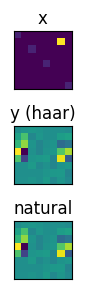

In [9]:
ch = 0 #check outchannel
h1 = lay.h1.numpy()[:,:,0,ch]

L = h1.shape[0]

# row_indices = tf.math.mod(n[:, tf.newaxis] - n, L)
Npoint = x.shape[1]
paddings = [
           [0, Npoint - L],  # height dimension
           [0, Npoint - L],  # width dimension
        ]
h1_padded = tf.pad(h1, paddings, mode='CONSTANT', constant_values=0)
h1_padded.shape

# import tensorflow as tf

# Example input
# N = 8  # Size of the tensor
# h = tf.reshape(tf.range(N * N, dtype=tf.float32), (N, N))  # Example tensor of shape (N, N)

# Create a meshgrid for n1, n2, k1, k2
n1 = tf.range(Npoint)  # [0, 1, ..., N-1]
n2 = tf.range(Npoint)  # [0, 1, ..., N-1]
k1 = tf.range(Npoint)  # [0, 1, ..., N-1]
k2 = tf.range(Npoint)  # [0, 1, ..., N-1]

# Create a grid of indices for n1, n2, k1, k2
n1, n2, k1, k2 = tf.meshgrid(n1, n2, k1, k2, indexing='ij')  # Shape (N, N, N, N)

# Compute circularly shifted indices
shifted_n1 = tf.math.mod(n1 - k1, Npoint)  # Circular shift for n1
shifted_n2 = tf.math.mod(n2 - k2, Npoint)  # Circular shift for n2

# Gather the values from h using the shifted indices
h_shifted = tf.gather_nd(h1_padded, tf.stack([shifted_n1, shifted_n2], axis=-1))

# Result
print("Original h:")
print(h1)
print("\nShape of h_shifted:", h_shifted.shape)
print("\nShifted h (first few elements):")
print(h_shifted[0, 0, 0:3, 0:3].numpy())  # Example slice for visualization
h_shifted.shape, h_shifted[5,4,:,:]
# h_shifted
h_shifted = tf.transpose(h_shifted,perm=[0,2,3,1])  # n1,:,:,n2



##verify natural
ynat = tf.einsum('bijc,uijv->buvc', xx[...,ch:ch+1], h_shifted)[0,:,:,0]

plt.figure(figsize=(2,3))
plt.subplot(3,1,1), plt.imshow(tf.squeeze(xx[ch,:,:,0]).numpy()), plt.title('x')
plt.xticks([]), plt.yticks([])
plt.subplot(3,1,2), plt.imshow(tf.squeeze(y[ch,:,:,0]).numpy()),  plt.title(f'y ({wave})')
plt.xticks([]), plt.yticks([])

plt.subplot(3,1,3), plt.imshow(ynat), plt.title('natural')
plt.xticks([]), plt.yticks([])

plt.tight_layout()

ynat, tf.round(y)[0,:,:,0]
tf.reduce_sum(tf.square(y[ch,...])), tf.reduce_sum(tf.square(ynat)), 


In [ ]:
ynat

<tf.Tensor: shape=(8, 8), dtype=float32, numpy=
array([[-0.5724209 , -0.334166  , -0.18908808, -0.08905342,  0.        ,
         0.        ,  0.        , -0.30860326],
       [ 0.4157582 , -0.986372  , -0.25921974, -0.2801869 ,  0.        ,
         0.        , -1.4559445 , -1.8468686 ],
       [-1.4696033 , -3.3801827 , -0.19782588, -0.3131357 ,  0.09109882,
        -0.08905342, -3.0860326 , -3.937094  ],
       [ 3.6410565 , -1.3528417 , -0.7002905 , -0.8100465 , -0.140125  ,
        -0.2801869 ,  0.93541294, -1.8662672 ],
       [-3.9168725 , -3.8322005 ,  0.09354129, -0.18662672,  0.18539417,
        -0.3131357 ,  3.402801  , -1.7079978 ],
       [ 0.        ,  0.        ,  0.33117023, -0.16189444, -0.7002905 ,
        -0.8100465 , -0.140125  , -0.2801869 ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.09354129,
        -0.18662672,  0.33098862, -0.11909473],
       [-0.19404098,  0.09109882, -0.08905342,  0.        ,  0.33117023,
        -0.16189444, -0.39168724

In [11]:
y[0,:,:,0], ynat[:,:]

(<tf.Tensor: shape=(8, 8), dtype=float32, numpy=
 array([[-7.8759469e-02,  1.9536652e-01,  2.9995632e-01,  1.6767697e-01,
         -5.5879350e-09,  9.3132257e-09, -1.0842653e-08, -1.2880537e-01],
        [ 6.9048518e-01,  1.9553140e+00, -2.8185862e-01,  2.5195017e-01,
         -5.5879350e-09,  9.3132257e-09,  5.3149015e-01,  7.1684009e-01],
        [ 1.4550974e+00,  3.0606380e+00,  2.0007601e-01, -3.7639692e-01,
          4.8006114e-02,  1.6767697e-01, -1.2880538e+00, -8.9925063e-01],
        [ 4.5243616e+00, -4.4752355e+00,  7.3100694e-02, -3.9543411e-01,
          1.4495242e-01,  2.5195017e-01,  2.1269870e+00,  3.3922968e+00],
        [ 2.0190606e+00, -2.6352570e+00,  2.1269870e-01,  3.3922964e-01,
          4.6360168e-01, -3.7639689e-01,  4.2463493e+00, -1.9035729e+00],
        [ 1.0575093e-08,  5.4524058e-08,  4.1983420e-01, -2.0712492e-01,
          7.3100723e-02, -3.9543414e-01,  1.4495245e-01,  2.5195038e-01],
        [-9.3132257e-09,  0.0000000e+00,  1.4901161e-08,  4.1772439e-

In [10]:
tolerance = 0.0001
diff = tf.abs(ynat - y[0,:,:,0])
are_equal_3dp = tf.reduce_all(diff < tolerance)

print("Are tensors equal up to 3 decimal places?", are_equal_3dp.numpy())

Are tensors equal up to 3 decimal places? True


In [12]:
# Compute the absolute difference
diff = tf.abs(ynat - y[0,:,:,0])

# Compute norms
numerator = tf.norm(diff)
denominator = tf.norm(ynat)

# Avoid division by zero
percentage_error = tf.cond(
    tf.equal(denominator, 0.0),
    lambda: tf.constant(0.0),
    lambda: (numerator / denominator) * 100
)

# Print the result
print("Percentage error:", percentage_error.numpy(), "%")


Percentage error: 1.2997786e-05 %


In [ ]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [49]:
tf.reduce_sum(tf.square(y2)), tf.reduce_sum(tf.square(q2)), 

NameError: name 'y2' is not defined

In [ ]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [2]:
mylibpath = [
    '/data1/kishoretarafdar/src.port/VolterraMRAsystems.v0/linear.Volterra.mra.live/mra'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from DWT1DFB import DWT1D, IDWT1D
from DWT2DFB import DWT2D, IDWT2D

ModuleNotFoundError: No module named 'TFDWT.GETDWTFiltersOrtho'

---

In [3]:
from TFDWT.DWT2DFB import DWT2D, IDWT2D

In [4]:
#%% Linear kernel for image input
import numpy as np
# x = [1,2,3,4,5,6,7,8]
# x = [1,0,0,0,0,0,0,0]
# x = [0,1,0,0,0,0,0,0]
# x = [0,0,1,0,0,0,0,0]
# x = [0,0,0,1,0,0,0,0]
# x = [0,0,0,0,1,0,0,0]
# x = [0,0,0,0,0,1,0,0]
# x = [0,0,0,0,0,0,1,0]
# x = [0,0,0,0,0,0,0,1]
# x = [0,0,0,1]
# x = [0,1,0,1,0,1,0,1]
x = np.array([[1,0,0,0,0,0,0,0], 
              [0,0,0,0,0,0,10,0], 
              [0,0,1,0,0,0,0,0],
              [0,0,0,0,0,0,0,0],
              [0,0,0,0,1,0,0,0],
              [0,0,0,0,0,0,0,0],
              [0,0,0,0,0,0,0,0],
              [0,0,0,0,0,0,0,1]], dtype=np.float32)
# x = np.array([[0,1,0,0,0,0,0,0], 
#               [0,0,0,0,0,0,0,0], 
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,0]])
# x = np.array([[0,0,0,0,0,0,0,0], 
#               [1,0,0,0,0,0,0,0], 
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,0]])              

wave = 'haar'
wave = 'db2'

h1 = np.array([[1, 2, 1], 
              [2, 4, 2], 
              [1, 2, 1]], dtype=np.float32)

# ## filter init
h1 = np.array([[1, 1, -1], 
              [1, 2, -1], 
              [1, -1, -1]], dtype=np.float32)

# h1 = np.array([[1, 1], 
#               [1, 21]])
## Matching filter size with input size with zero padding
L = h1.shape[0]

# row_indices = tf.math.mod(n[:, tf.newaxis] - n, L)
Npoint = x.shape[0]
paddings = [
           [0, Npoint - L],  # height dimension
           [0, Npoint - L],  # width dimension
        ]
h1_padded = tf.pad(h1, paddings, mode='CONSTANT', constant_values=0)
h1_padded.shape

# import tensorflow as tf

# Example input
# N = 8  # Size of the tensor
# h = tf.reshape(tf.range(N * N, dtype=tf.float32), (N, N))  # Example tensor of shape (N, N)

# Create a meshgrid for n1, n2, k1, k2
n1 = tf.range(Npoint)  # [0, 1, ..., N-1]
n2 = tf.range(Npoint)  # [0, 1, ..., N-1]
k1 = tf.range(Npoint)  # [0, 1, ..., N-1]
k2 = tf.range(Npoint)  # [0, 1, ..., N-1]

# Create a grid of indices for n1, n2, k1, k2
n1, n2, k1, k2 = tf.meshgrid(n1, n2, k1, k2, indexing='ij')  # Shape (N, N, N, N)

# Compute circularly shifted indices
shifted_n1 = tf.math.mod(n1 - k1, Npoint)  # Circular shift for n1
shifted_n2 = tf.math.mod(n2 - k2, Npoint)  # Circular shift for n2

# Gather the values from h using the shifted indices
h_shifted = tf.gather_nd(h1_padded, tf.stack([shifted_n1, shifted_n2], axis=-1))

# Result
print("Original h:")
print(h1)
print("\nShape of h_shifted:", h_shifted.shape)
print("\nShifted h (first few elements):")
print(h_shifted[0, 0, 0:3, 0:3].numpy())  # Example slice for visualization
h_shifted.shape, h_shifted[5,4,:,:]
# h_shifted
h_shifted = tf.transpose(h_shifted,perm=[0,2,3,1])  # n1,:,:,n2
h_init = DWT2D(wave, clean=False)(tf.cast(h_shifted, dtype=tf.float32))
h_init.shape

2025-06-21 08:00:15.333862: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 16.00GiB (17179869184 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


Original h:
[[ 1.  1. -1.]
 [ 1.  2. -1.]
 [ 1. -1. -1.]]

Shape of h_shifted: (8, 8, 8, 8)

Shifted h (first few elements):
[[1. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


TensorShape([8, 8, 8, 8])

In [5]:
h_initT = tf.transpose(h_init, perm=[1,0,3,2])
# h_initT[0,:,:,0]
H = DWT2D(wave, clean=False)(h_initT)
HT = tf.transpose(H, perm=[1,0,3,2])
HT

<tf.Tensor: shape=(8, 8, 8, 8), dtype=float32, numpy=
array([[[[ 2.75781250e+00, -3.67187530e-01, -1.32812500e-01, ...,
          -5.66837072e-01,  3.55870053e-02, -4.95662987e-01],
         [-1.32812500e-01,  2.75781250e+00, -3.67187560e-01, ...,
           1.02691305e+00, -5.66837072e-01,  3.55870053e-02],
         [-1.32812500e-01, -1.32812500e-01,  2.75781250e+00, ...,
          -4.95662987e-01,  1.02691305e+00, -5.66837072e-01],
         ...,
         [ 3.55870053e-02, -5.66837013e-01,  1.02691305e+00, ...,
           3.67187560e-01, -2.75781250e+00,  1.32812500e-01],
         [-4.95662987e-01,  3.55870053e-02, -5.66837013e-01, ...,
           1.32812500e-01,  3.67187560e-01, -2.75781250e+00],
         [ 1.02691305e+00, -4.95662987e-01,  3.55870053e-02, ...,
           1.32812500e-01,  1.32812500e-01,  3.67187560e-01]],

        [[-1.32812515e-01, -7.81249627e-03,  7.81250186e-03, ...,
           3.33433524e-02, -2.09335354e-03,  2.91566458e-02],
         [ 7.81249860e-03, -1.3281

In [6]:
x.shape

(8, 8)

In [7]:
# H = DWT2D(wave)(h_init)
# n1,n2 = 6,5
# print('H1 shape ',H.shape)
# h_shifted[n1,:,:,n2], h_init[n1,:,:,n2], 
# H[n1,:,:,n2]

# prepare x 
x = tf.constant(x)
x
x = tf.expand_dims(tf.expand_dims(x, axis=0),axis=-1)
x.shape




TensorShape([1, 8, 8, 1])

In [8]:
α = DWT2D(wave, clean=False)(tf.cast(x, dtype=tf.float32))
α.shape

TensorShape([1, 8, 8, 1])

(1, 8, 8, 1) tf.Tensor(
[[ 3.0000010e+00 -4.0233135e-07 -1.0000001e+00  5.5879354e-09
  -1.1175871e-07 -6.9249246e-09 -1.4901161e-07  9.9999928e-01]
 [-1.0000001e+01  9.9999940e-01 -9.9999964e-01 -1.0244548e-07
   0.0000000e+00  2.1298455e-07  1.0000000e+01  1.1000000e+01]
 [-9.0000019e+00 -9.9999917e-01  3.8743019e-07  9.9999982e-01
  -1.0000000e+00 -1.4342368e-07  1.0000000e+01  2.0000002e+01]
 [-1.0000001e+01  4.8987567e-07  1.0000005e+00  2.0000000e+00
  -1.0000004e+00 -9.4994903e-08  1.0000002e+01 -1.0000002e+01]
 [ 9.8347664e-07 -2.2351742e-08  9.9999994e-01 -9.9999982e-01
  -1.5646219e-07  9.9999976e-01 -1.0000005e+00 -6.1839819e-07]
 [-3.7252903e-07  5.2154064e-08  1.8067658e-07 -3.0547380e-07
   9.9999994e-01  1.9999999e+00 -1.0000006e+00  2.7567148e-07]
 [-4.1723251e-07  8.9406967e-08 -1.4901161e-08  6.7055225e-08
   1.0000001e+00 -1.0000001e+00 -1.0000001e+00 -5.9604645e-08]
 [ 9.9999994e-01 -1.0000000e+00  3.7252903e-08 -1.4901161e-08
  -2.9802322e-08 -5.9604645e-08 -3.4272

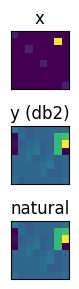

In [9]:

## convolution like in wavelet domain
β = tf.einsum('bijc,uijv->buvc',α,HT)

# β = tf.einsum('bic,ij->bjc',α,H)
β.shape
β
y = IDWT2D(wave, clean=False)(β)
print(y.shape,y[0,:,:,0])

# alpha1 = α
# beta1 = β
# alpha1, beta1 

##verify natural
ynat = tf.einsum('bijc,uijv->buvc', x, h_shifted)[0,:,:,0]

plt.figure(figsize=(2,3))
plt.subplot(3,1,1), plt.imshow(tf.squeeze(x).numpy()), plt.title('x')
plt.xticks([]), plt.yticks([])
plt.subplot(3,1,2), plt.imshow(tf.squeeze(y).numpy()),  plt.title(f'y ({wave})')
plt.xticks([]), plt.yticks([])

plt.subplot(3,1,3), plt.imshow(ynat), plt.title('natural')
plt.xticks([]), plt.yticks([])

plt.tight_layout()


In [ ]:
# h_shifted, x

In [10]:
ynat, tf.round(y)[0,:,:,0]

(<tf.Tensor: shape=(8, 8), dtype=float32, numpy=
 array([[  3.,   0.,  -1.,   0.,   0.,   0.,   0.,   1.],
        [-10.,   1.,  -1.,   0.,   0.,   0.,  10.,  11.],
        [ -9.,  -1.,   0.,   1.,  -1.,   0.,  10.,  20.],
        [-10.,   0.,   1.,   2.,  -1.,   0.,  10., -10.],
        [  0.,   0.,   1.,  -1.,   0.,   1.,  -1.,   0.],
        [  0.,   0.,   0.,   0.,   1.,   2.,  -1.,   0.],
        [  0.,   0.,   0.,   0.,   1.,  -1.,  -1.,   0.],
        [  1.,  -1.,   0.,   0.,   0.,   0.,   0.,   1.]], dtype=float32)>,
 <tf.Tensor: shape=(8, 8), dtype=float32, numpy=
 array([[  3.,   0.,  -1.,   0.,   0.,   0.,   0.,   1.],
        [-10.,   1.,  -1.,   0.,   0.,   0.,  10.,  11.],
        [ -9.,  -1.,   0.,   1.,  -1.,   0.,  10.,  20.],
        [-10.,   0.,   1.,   2.,  -1.,   0.,  10., -10.],
        [  0.,   0.,   1.,  -1.,   0.,   1.,  -1.,   0.],
        [  0.,   0.,   0.,   0.,   1.,   2.,  -1.,   0.],
        [  0.,   0.,   0.,   0.,   1.,  -1.,  -1.,   0.],
        [  1.,

In [11]:
tf.reduce_sum(tf.square(y)), tf.reduce_sum(tf.square(ynat)), 

(<tf.Tensor: shape=(), dtype=float32, numpy=1240.000244140625>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1240.0>)

In [12]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

    SISO

In [13]:
class MRAVoltImage(tf.keras.layers.Layer):
    """MRA Volterra Kernel
       Input: image x[n1,n2]
       Output: Shift invariant linear monomial y1, i.e., m=1

       --@KKT, 12-Feb-2025
    
    """
    
    def __init__(self, kernel_size=4, wave='haar', **kwargs):
        super(MRAVoltImage, self).__init__(**kwargs)
        self.L = kernel_size
        self.wave = wave
        # self.filters = out_channels
    
    def build(self, input_shape):
        # input_shape: (batch_size, N, N, channels)
        self.N = input_shape[1]
        self.channels = input_shape[-1]

        # kernel_shape = (self.L, self.L, input_shape[-1], self.filters)
        kernel_shape = (self.L, self.L)
        self.h1 = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            # regularizer=self.kernel_regularizer,
            name='kernel'
        )
        super(MRAVoltImage, self).build(input_shape)
    

    def call(self, x):

        HT = self.__getH()

        α = DWT2D(self.wave, clean=False)(tf.cast(x, dtype=tf.float32))
        # α.shape

        ## convolution like in wavelet domain
        β = tf.einsum('bijc,uijv->buvc',α,HT)
        # β
        y = IDWT2D(self.wave, clean=False)(β)

        # ynatural = tf.einsum('bijc,uijv->buvc', x, tf.cast(self.h_shifted, tf.float32))[0,:,:,0]
        
        return y#, ynatural

    def __getH(self):
        # Npoint = self.N
        paddings = [
           [0, self.N - L],  # height dimension
           [0, self.N - L],  # width dimension
        #    [0,0]
        #    [0,0] 
        ]
        h1 = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)

        # Create a meshgrid for n1, n2, k1, k2
        n1 = tf.range(self.N)  # [0, 1, ..., N-1]
        n2 = tf.range(self.N)  # [0, 1, ..., N-1]
        k1 = tf.range(self.N)  # [0, 1, ..., N-1]
        k2 = tf.range(self.N)  # [0, 1, ..., N-1]

        # Create a grid of indices for n1, n2, k1, k2
        n1, n2, k1, k2 = tf.meshgrid(n1, n2, k1, k2, indexing='ij')  # Shape (N, N, N, N)

        # Compute circularly shifted indices
        shifted_n1 = tf.math.mod(n1 - k1, self.N)  # Circular shift for n1
        shifted_n2 = tf.math.mod(n2 - k2, self.N)  # Circular shift for n2

        # Gather the values from h using the shifted indices
        h1_shifted = tf.gather_nd(h1, tf.stack([shifted_n1, shifted_n2], axis=-1))
        h1_shifted = tf.transpose(h1_shifted,perm=[0,2,3,1])  # n1,:,:,n2

        # for in channels
        # tmp = [DWT2D(self.wave)(tf.cast(h1_shifted[...,i], dtype=tf.float32)) for i in range(self.channels)
        # tmp = [tf.transpose(h1_n_l, perm=[1,0,3,2]) for h1_n_l tmp]
        # tmp = [DWT2D(self.wave)(h1_n_lT) for h1_n_lT in tmp]
        # tmp = [tf.expand_dims(tf.transpose(H, perm=[1,0,3,2]), axis=-1) for H in tmp]
        # tmp = tf.stack(tmp, axis=-1)
        
        h1_n_l = DWT2D(self.wave, clean=False)(tf.cast(h1_shifted, dtype=tf.float32))
        h1_n_l.shape
        h1_n_lT = tf.transpose(h1_n_l, perm=[1,0,3,2])
        # h_initT[0,:,:,0]
        H = DWT2D(self.wave, clean=False)(h1_n_lT)
        HT = tf.transpose(H, perm=[1,0,3,2])
        # self.h_shifted = h_shifted        
        return HT
    
    def get_config(self):
        base_config = super(MRAVoltImage, self).get_config()
        return base_config

lay = MRAVoltImage()
y = lay(x)

In [14]:
lay.h1.numpy().dtype

dtype('float32')

Original h:
[[-0.25564128 -0.5767821   0.30702633  0.0621447 ]
 [ 0.3678941  -0.59551656  0.01623154  0.09028375]
 [-0.1689713   0.7619211   0.351075    0.59008306]
 [-0.5485022  -0.08835191 -0.67387974  0.07806385]]

Shape of h_shifted: (8, 8, 8, 8)

Shifted h (first few elements):
[[-0.25564128  0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]]


(<tf.Tensor: shape=(), dtype=float32, numpy=299.1732482910156>,
 <tf.Tensor: shape=(), dtype=float32, numpy=299.17327880859375>)

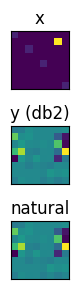

In [15]:
h1 = lay.h1.numpy()

L = h1.shape[0]

# row_indices = tf.math.mod(n[:, tf.newaxis] - n, L)
Npoint = x.shape[1]
paddings = [
           [0, Npoint - L],  # height dimension
           [0, Npoint - L],  # width dimension
        ]
h1_padded = tf.pad(h1, paddings, mode='CONSTANT', constant_values=0)
h1_padded.shape

# import tensorflow as tf

# Example input
# N = 8  # Size of the tensor
# h = tf.reshape(tf.range(N * N, dtype=tf.float32), (N, N))  # Example tensor of shape (N, N)

# Create a meshgrid for n1, n2, k1, k2
n1 = tf.range(Npoint)  # [0, 1, ..., N-1]
n2 = tf.range(Npoint)  # [0, 1, ..., N-1]
k1 = tf.range(Npoint)  # [0, 1, ..., N-1]
k2 = tf.range(Npoint)  # [0, 1, ..., N-1]

# Create a grid of indices for n1, n2, k1, k2
n1, n2, k1, k2 = tf.meshgrid(n1, n2, k1, k2, indexing='ij')  # Shape (N, N, N, N)

# Compute circularly shifted indices
shifted_n1 = tf.math.mod(n1 - k1, Npoint)  # Circular shift for n1
shifted_n2 = tf.math.mod(n2 - k2, Npoint)  # Circular shift for n2

# Gather the values from h using the shifted indices
h_shifted = tf.gather_nd(h1_padded, tf.stack([shifted_n1, shifted_n2], axis=-1))

# Result
print("Original h:")
print(h1)
print("\nShape of h_shifted:", h_shifted.shape)
print("\nShifted h (first few elements):")
print(h_shifted[0, 0, 0:3, 0:3].numpy())  # Example slice for visualization
h_shifted.shape, h_shifted[5,4,:,:]
# h_shifted
h_shifted = tf.transpose(h_shifted,perm=[0,2,3,1])  # n1,:,:,n2



##verify natural
ynat = tf.einsum('bijc,uijv->buvc', x, h_shifted)[0,:,:,0]

plt.figure(figsize=(2,3))
plt.subplot(3,1,1), plt.imshow(tf.squeeze(x).numpy()), plt.title('x')
plt.xticks([]), plt.yticks([])
plt.subplot(3,1,2), plt.imshow(tf.squeeze(y).numpy()),  plt.title(f'y ({wave})')
plt.xticks([]), plt.yticks([])

plt.subplot(3,1,3), plt.imshow(ynat), plt.title('natural')
plt.xticks([]), plt.yticks([])

plt.tight_layout()

ynat, tf.round(y)[0,:,:,0]
tf.reduce_sum(tf.square(y)), tf.reduce_sum(tf.square(ynat)), 


        MIMO 

In [3]:
import numpy as np
x = np.array([[1,0,0,0,0,0,0,0], 
              [0,0,0,0,0,0,10,0], 
              [0,0,1,0,0,0,0,0],
              [0,0,0,0,0,0,0,0],
              [0,0,0,0,1,0,0,0],
              [0,0,0,0,0,0,0,0],
              [0,0,0,0,0,0,0,0],
              [0,0,0,0,0,0,0,1]], dtype=np.float32)
x = tf.expand_dims(tf.expand_dims(x, axis=0),axis=-1)
x.shape
xx = tf.concat([x,x], axis=-1)
xx.shape

2025-06-29 01:27:54.140163: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-06-29 01:27:54.140206: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: meherangarh
2025-06-29 01:27:54.140214: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: meherangarh
2025-06-29 01:27:54.140323: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 570.148.8
2025-06-29 01:27:54.140348: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 570.148.8
2025-06-29 01:27:54.140354: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:259] kernel version seems to match DSO: 570.148.8


TensorShape([1, 8, 8, 2])

In [4]:
class MRAVoltImage(tf.keras.layers.Layer):
    """MRA Volterra Kernel
       Input: image x[n1,n2]
       Output: Shift invariant linear monomial y1, i.e., m=1

       --@KKT, 12-Feb-2025
    
    """
    
    def __init__(self, kernel_size=4, wave='haar', **kwargs):
        super(MRAVoltImage, self).__init__(**kwargs)
        self.L = kernel_size
        self.wave = wave
        # self.filters = out_channels
    
    def build(self, input_shape):
        # input_shape: (batch_size, N, N, channels)
        self.N = input_shape[1]
        self.channels = input_shape[-1]

        # kernel_shape = (self.L, self.L, input_shape[-1], self.filters)
        kernel_shape = (self.L, self.L, input_shape[-1])
        self.h1 = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            # regularizer=self.kernel_regularizer,
            name='kernel'
        )
        super(MRAVoltImage, self).build(input_shape)
    

    def call(self, x):

        HT = self.__getH()

        α = DWT2D(self.wave, clean=False)(tf.cast(x, dtype=tf.float32))
        # α.shape

        ## convolution like in wavelet domain
        β = tf.einsum('bijc,uijvc->buvc',α,HT)
        # β
        y = IDWT2D(self.wave, clean=False)(β)

        # ynatural = tf.einsum('bijc,uijv->buvc', x, tf.cast(self.h_shifted, tf.float32))[0,:,:,0]
        
        return y#, ynatural

    def __getH(self):
        # Npoint = self.N
        paddings = [
           [0, self.N - L],  # height dimension
           [0, self.N - L],  # width dimension
           [0,0]
        #    [0,0] 
        ]
        h1 = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)

        # Create a meshgrid for n1, n2, k1, k2
        n1 = tf.range(self.N)  # [0, 1, ..., N-1]
        n2 = tf.range(self.N)  # [0, 1, ..., N-1]
        k1 = tf.range(self.N)  # [0, 1, ..., N-1]
        k2 = tf.range(self.N)  # [0, 1, ..., N-1]

        # Create a grid of indices for n1, n2, k1, k2
        n1, n2, k1, k2 = tf.meshgrid(n1, n2, k1, k2, indexing='ij')  # Shape (N, N, N, N)

        # Compute circularly shifted indices
        shifted_n1 = tf.math.mod(n1 - k1, self.N)  # Circular shift for n1
        shifted_n2 = tf.math.mod(n2 - k2, self.N)  # Circular shift for n2

        # Gather the values from h using the shifted indices
        h1_shifted = tf.gather_nd(h1, tf.stack([shifted_n1, shifted_n2], axis=-1))
        h1_shifted = tf.transpose(h1_shifted,perm=[0,2,3,1,4])  # n1,:,:,n2 01234
        print('++', h1_shifted.shape)
        
        # for in channels
        h1_n_l = [DWT2D(self.wave, clean=False)(tf.cast(h1_shifted[...,i], dtype=tf.float32)) for i in range(self.channels)]
        print('++', len(h1_n_l))
        h1_n_lT = [tf.transpose(_, perm=[1,0,3,2]) for _ in h1_n_l]
        print('++', len(h1_n_lT), h1_n_lT[0].shape)
        H = [DWT2D(self.wave, clean=False)(_) for _ in h1_n_lT]
        # HT = [tf.transpose(H, perm=[1,0,3,2]) for _ in H]
        HT = [tf.transpose(H, perm=[1,0,3,2]) for H in H]
        print('>',len(HT))
        HT = tf.stack(HT, axis=-1)
        print('>',HT.shape)

    
        

        # h1_n_l = DWT2D(self.wave)(tf.cast(h1_shifted, dtype=tf.float32))
        # h1_n_l.shape
        # h1_n_lT = tf.transpose(h1_n_l, perm=[1,0,3,2])
        # # h_initT[0,:,:,0]
        # H = DWT2D(self.wave)(h1_n_lT)
        # HT = tf.transpose(H, perm=[1,0,3,2])
          
        return HT
    
    def get_config(self):
        base_config = super(MRAVoltImage, self).get_config()
        return base_config

lay = MRAVoltImage()
y = lay(xx)

NameError: Exception encountered when calling MRAVoltImage.call().

[1mname 'L' is not defined[0m

Arguments received by MRAVoltImage.call():
  • x=tf.Tensor(shape=(1, 8, 8, 2), dtype=float32)

In [5]:
lay.h1.numpy().shape

(4, 4, 2)

Original h:
[[ 0.49013686  0.28116357  0.22368205 -0.3323356 ]
 [ 0.2458986   0.25096118 -0.01741064  0.01386511]
 [-0.4725604   0.36961198  0.48699462 -0.06880295]
 [-0.27320933 -0.39821398 -0.21812415  0.20180094]]

Shape of h_shifted: (8, 8, 8, 8)

Shifted h (first few elements):
[[0.49013686 0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]]


(<tf.Tensor: shape=(), dtype=float32, numpy=154.63406372070312>,
 <tf.Tensor: shape=(), dtype=float32, numpy=154.63409423828125>)

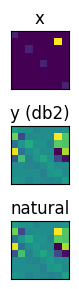

In [19]:
ch = 1 #check channel
h1 = lay.h1.numpy()[...,ch]

L = h1.shape[0]

# row_indices = tf.math.mod(n[:, tf.newaxis] - n, L)
Npoint = x.shape[1]
paddings = [
           [0, Npoint - L],  # height dimension
           [0, Npoint - L],  # width dimension
        ]
h1_padded = tf.pad(h1, paddings, mode='CONSTANT', constant_values=0)
h1_padded.shape

# import tensorflow as tf

# Example input
# N = 8  # Size of the tensor
# h = tf.reshape(tf.range(N * N, dtype=tf.float32), (N, N))  # Example tensor of shape (N, N)

# Create a meshgrid for n1, n2, k1, k2
n1 = tf.range(Npoint)  # [0, 1, ..., N-1]
n2 = tf.range(Npoint)  # [0, 1, ..., N-1]
k1 = tf.range(Npoint)  # [0, 1, ..., N-1]
k2 = tf.range(Npoint)  # [0, 1, ..., N-1]

# Create a grid of indices for n1, n2, k1, k2
n1, n2, k1, k2 = tf.meshgrid(n1, n2, k1, k2, indexing='ij')  # Shape (N, N, N, N)

# Compute circularly shifted indices
shifted_n1 = tf.math.mod(n1 - k1, Npoint)  # Circular shift for n1
shifted_n2 = tf.math.mod(n2 - k2, Npoint)  # Circular shift for n2

# Gather the values from h using the shifted indices
h_shifted = tf.gather_nd(h1_padded, tf.stack([shifted_n1, shifted_n2], axis=-1))

# Result
print("Original h:")
print(h1)
print("\nShape of h_shifted:", h_shifted.shape)
print("\nShifted h (first few elements):")
print(h_shifted[0, 0, 0:3, 0:3].numpy())  # Example slice for visualization
h_shifted.shape, h_shifted[5,4,:,:]
# h_shifted
h_shifted = tf.transpose(h_shifted,perm=[0,2,3,1])  # n1,:,:,n2



##verify natural
ynat = tf.einsum('bijc,uijv->buvc', xx[...,ch:ch+1], h_shifted)[0,:,:,0]

plt.figure(figsize=(2,3))
plt.subplot(3,1,1), plt.imshow(tf.squeeze(xx[...,ch]).numpy()), plt.title('x')
plt.xticks([]), plt.yticks([])
plt.subplot(3,1,2), plt.imshow(tf.squeeze(y[...,ch]).numpy()),  plt.title(f'y ({wave})')
plt.xticks([]), plt.yticks([])

plt.subplot(3,1,3), plt.imshow(ynat), plt.title('natural')
plt.xticks([]), plt.yticks([])

plt.tight_layout()

ynat, tf.round(y)[0,:,:,0]
tf.reduce_sum(tf.square(y[...,ch])), tf.reduce_sum(tf.square(ynat)), 


In [ ]:
# import numpy as np
# x = np.array([[1,0,0,0,0,0,0,0], 
#               [0,0,0,0,0,0,10,0], 
#               [0,0,1,0,0,0,0,0],
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,1,0,0,0],
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,1]], dtype=np.float32)
# x = tf.expand_dims(tf.expand_dims(x, axis=0),axis=-1)
# x.shape
# xx = tf.concat([x,x], axis=0)
# xx.shape

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [ ]:
class MRAVoltImage(tf.keras.layers.Layer):
    """MRA Volterra Kernel
       Input: image x[n1,n2]
       Output: Shift invariant linear monomial y1, i.e., m=1

       --@KKT, 12-Feb-2025
    
    """
    
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super(MRAVoltImage, self).__init__(**kwargs)
        self.L = kernel_size
        self.wave = wave
        self.filters = filters
    
    def build(self, input_shape):
        # input_shape: (batch_size, N, N, channels)
        self.N = input_shape[1]
        self.channels = input_shape[-1]

        kernel_shape = (self.L, self.L, input_shape[-1], self.filters)
        # kernel_shape = (self.L, self.L, input_shape[-1])
        self.h1 = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            # regularizer=self.kernel_regularizer,
            name='kernel'
        )
        self.T = input_shape[-1] * self.filters 
        super(MRAVoltImage, self).build(input_shape)
    

    def call(self, x):

        HT = self.__getH()

        α = DWT2D(self.wave)(tf.cast(x, dtype=tf.float32))
        # α.shape

        ## convolution like in wavelet domain
        β = tf.einsum('bijc,uijvco->buvco',α,HT)
        β = tf.einsum('buvco->buvo',β)
        # β
        y = IDWT2D(self.wave)(β)

        # ynatural = tf.einsum('bijc,uijv->buvc', x, tf.cast(self.h_shifted, tf.float32))[0,:,:,0]
        
        return y#, ynatural

    def __getH(self):
        # Npoint = self.N
        paddings = [
           [0, self.N - self.L],  # height dimension
           [0, self.N - self.L],  # width dimension
           [0,0],
           [0,0] 
        ]
        h1 = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)

        # Create a meshgrid for n1, n2, k1, k2
        n1 = tf.range(self.N)  # [0, 1, ..., N-1]
        n2 = tf.range(self.N)  # [0, 1, ..., N-1]
        k1 = tf.range(self.N)  # [0, 1, ..., N-1]
        k2 = tf.range(self.N)  # [0, 1, ..., N-1]

        # Create a grid of indices for n1, n2, k1, k2
        n1, n2, k1, k2 = tf.meshgrid(n1, n2, k1, k2, indexing='ij')  # Shape (N, N, N, N)

        # Compute circularly shifted indices
        shifted_n1 = tf.math.mod(n1 - k1, self.N)  # Circular shift for n1
        shifted_n2 = tf.math.mod(n2 - k2, self.N)  # Circular shift for n2

        # Gather the values from h using the shifted indices
        h1_shifted = tf.gather_nd(h1, tf.stack([shifted_n1, shifted_n2], axis=-1))
        h1_shifted = tf.transpose(h1_shifted,perm=[0,2,3,1,4,5])  # n1,:,:,n2 01234
        # print('++', h1_shifted.shape)
        



        _ = tf.unstack(h1_shifted, axis=-1)
        # print('++', [__.shape for __ in _])
        _ = tf.concat(_, axis=-1)
        # print('_1',_.shape)
        _ = tf.unstack(_, axis=-1)
        _ = tf.concat(_, axis=-1)
        _ = DWT2D(self.wave)(_)
        # print('_2',_.shape)
        # print('_2.5',[_[...,self.N*i:self.N*i+self.N].shape for i in range(self.T)])
        _ = tf.concat([tf.transpose(_[...,self.N*i:self.N*i+self.N], perm=[1,0,3,2]) for i in range(self.T)], axis=-1)
        
        _ = DWT2D(self.wave)(_)
        
        # print('>',_.shape)
        pqrs = [tf.transpose(_[...,self.N*i:self.N*i+self.N], perm=[1,0,3,2]) for i in range(self.T)]
        # print('_3',[_.shape for _ in pqrs])
        # i=0
        # print('?', tf.stack(pqrs[self.channels*i:self.channels*i+self.channels],axis=-1).shape)
        HT = tf.stack([tf.stack(pqrs[self.channels*i:self.channels*i+self.channels],axis=-1) for i in range(self.filters)], axis=-1)
        # print('HT',HT.shape)

        return HT
    
    def get_config(self):
        base_config = super(MRAVoltImage, self).get_config()
        return base_config

lay = MRAVoltImage(filters=1)
y = lay(xx)
y.shape

TensorShape([2, 8, 8, 1])

Original h:
[[ 0.10964379 -0.24030174 -0.17167318  0.20082107]
 [ 0.05041859 -0.13490972  0.2131159  -0.3484653 ]
 [ 0.3461282  -0.2098482  -0.02436918  0.07910165]
 [ 0.35091254  0.01230145  0.3147519   0.07142118]]

Shape of h_shifted: (8, 8, 8, 8)

Shifted h (first few elements):
[[0.10964379 0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]]


(<tf.Tensor: shape=(), dtype=float32, numpy=72.06832885742188>,
 <tf.Tensor: shape=(), dtype=float32, numpy=72.068359375>)

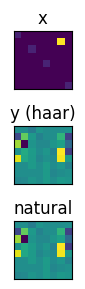

In [ ]:
ch = 0 #check outchannel
b = 1
h1 = lay.h1.numpy()[:,:,0,ch]

L = h1.shape[0]

# row_indices = tf.math.mod(n[:, tf.newaxis] - n, L)
Npoint = x.shape[1]
paddings = [
           [0, Npoint - L],  # height dimension
           [0, Npoint - L],  # width dimension
        ]
h1_padded = tf.pad(h1, paddings, mode='CONSTANT', constant_values=0)
h1_padded.shape

# import tensorflow as tf

# Example input
# N = 8  # Size of the tensor
# h = tf.reshape(tf.range(N * N, dtype=tf.float32), (N, N))  # Example tensor of shape (N, N)

# Create a meshgrid for n1, n2, k1, k2
n1 = tf.range(Npoint)  # [0, 1, ..., N-1]
n2 = tf.range(Npoint)  # [0, 1, ..., N-1]
k1 = tf.range(Npoint)  # [0, 1, ..., N-1]
k2 = tf.range(Npoint)  # [0, 1, ..., N-1]

# Create a grid of indices for n1, n2, k1, k2
n1, n2, k1, k2 = tf.meshgrid(n1, n2, k1, k2, indexing='ij')  # Shape (N, N, N, N)

# Compute circularly shifted indices
shifted_n1 = tf.math.mod(n1 - k1, Npoint)  # Circular shift for n1
shifted_n2 = tf.math.mod(n2 - k2, Npoint)  # Circular shift for n2

# Gather the values from h using the shifted indices
h_shifted = tf.gather_nd(h1_padded, tf.stack([shifted_n1, shifted_n2], axis=-1))

# Result
print("Original h:")
print(h1)
print("\nShape of h_shifted:", h_shifted.shape)
print("\nShifted h (first few elements):")
print(h_shifted[0, 0, 0:3, 0:3].numpy())  # Example slice for visualization
h_shifted.shape, h_shifted[5,4,:,:]
# h_shifted
h_shifted = tf.transpose(h_shifted,perm=[0,2,3,1])  # n1,:,:,n2



##verify natural
ynat = tf.einsum('bijc,uijv->buvc', xx[...,ch:ch+1], h_shifted)[0,:,:,0]

plt.figure(figsize=(2,3))
plt.subplot(3,1,1), plt.imshow(tf.squeeze(xx[b,:,:,0]).numpy()), plt.title('x')
plt.xticks([]), plt.yticks([])
plt.subplot(3,1,2), plt.imshow(tf.squeeze(y[b,:,:,0]).numpy()),  plt.title(f'y ({wave})')
plt.xticks([]), plt.yticks([])

plt.subplot(3,1,3), plt.imshow(ynat), plt.title('natural')
plt.xticks([]), plt.yticks([])

plt.tight_layout()

ynat, tf.round(y)[0,:,:,0]
tf.reduce_sum(tf.square(y[ch,...])), tf.reduce_sum(tf.square(ynat)), 


In [ ]:
# @tf.function
def mra2D(x, wave='haar'):
    N = x.shape[1]
    l1H1 = DWT2D(wave)(x)
    l1 = l1H1[:,:N//2,:N//2,:]
    H1 = l1H1[:,N//2:,N//2:,:]
    
    #level 2
    l2H2 = DWT2D(wave)(l1)
    # l2 = l2H2[:,:N//4,:N//4,:]

    #level 3
    # l3H3 = DWT2D(wave)(l2)
    # l3 = l3H3[:,:N//8,:N//8,:]
    # _ = tf.zeros_like(x)  # Initialize a tensor of zeros with the same shape as S
    # _[:, :N//2, :N//2, :] = l2H2  # Assign p to the top-left corner
    # _[:, N//2:, N//2:, :] = H1  # Assign q to the bottom-right corner


    # _ = tf.concat([tf.concat([l2H2, H1], axis=2), tf.concat([H1, l2H2], axis=2)], axis=1)
    # _ = IDWT2D(wave)(_)



    # # Create an empty tensor of shape (1, 8, 8, 1)
    # S = tf.zeros((1, 8, 8, 2), dtype=l2H2.dtype)
    # print(S.shape)

    # # Place p in the top-left quadrant
    # S = tf.tensor_scatter_nd_update(
    #     S,
    #     indices=[[0, i, j, 0] for i in range(4) for j in range(4)],
    #     updates=tf.reshape(l2H2, [-1])
    # )

    # # Place q in the bottom-right quadrant
    # S = tf.tensor_scatter_nd_update(
    #     S,
    #     indices=[[0, i + 4, j + 4, 0] for i in range(4) for j in range(4)],
    #     updates=tf.reshape(H1, [-1]) 
    # )

    # print(tf.reduce_all(tf.equal(x, S)))

    # return _
    

    # print(l1.shape, l2H2.shape)
    # print(tf.concat([l2H2, H1], axis=[1,2]))

    S = tf.concat([l2H2, H1], axis=2) # Concatenate along the 3rd dimension

    S = tf.concat([S[:,:,:N//2,:],S[:,:,N//2:,:]],axis=1) # Concatenate along the 2nd dimension
    # print(tf.concat([l2H2, H1], axis=2).shape)
    # print(tf.concat([H1, l2H2], axis=2).shape)
    # _ = tf.concat([tf.concat([l2H2, H1], axis=2), tf.concat([H1, l2H2], axis=2)], axis=1)
    # print(tf.concat([tf.concat([l2H2, H1], axis=2), tf.concat([H1, l2H2], axis=2)], axis=1).shape)
    # print(tf.reduce_all(tf.equal(S,x)))
    print(S.shape)



# _ = 
mra2D(xx)
# _.shape



(2, 8, 4, 1)


TypeError: tuple indices must be integers or slices, not tuple

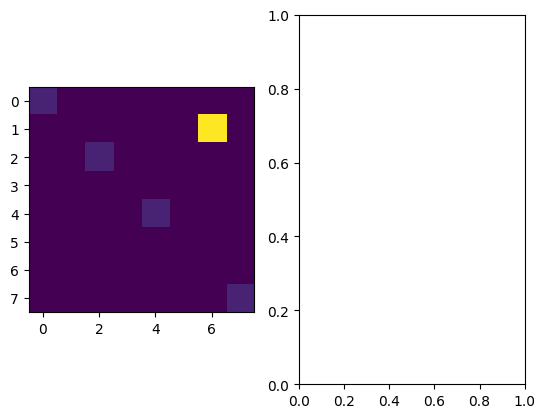

In [ ]:
plt.subplot(121), plt.imshow(x[0,:,:,0])
plt.subplot(122), plt.imshow(_[0,:,:,0])